## 1.0) Setup

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.utils.data import Dataset

In [3]:
from pathlib import Path

root_dir = Path('D:/SipakMed')

# Definindo as labels
sipakmed_labels = {0:'im_Dyskeratotic', 1:'im_Koilocytotic', 2:'im_Metaplastic', 3:'im_Parabasal', 4:'im_Superficial-Intermediate'}

data_dir = [root_dir / 'im_Dyskeratotic' / 'im_Dyskeratotic' / 'CROPPED',
            root_dir / 'im_Koilocytotic' / 'im_Koilocytotic' / 'CROPPED',
            root_dir / 'im_Metaplastic' / 'im_Metaplastic' / 'CROPPED',
            root_dir / 'im_Parabasal' / 'im_Parabasal' / 'CROPPED',
            root_dir / 'im_Superficial-Intermediate' / 'im_Superficial-Intermediate' / 'CROPPED']

## 1.1) Data overview

In [4]:
sipakmed_length = []
for i in range(5):
    total = 0
    for arquivo in data_dir[i].iterdir():
        if arquivo.is_file():
            if arquivo.name.split('.')[-1] == 'png':
                total += 1
    sipakmed_length.append(total)
    print(f'Classe {sipakmed_labels[i]}: {total}')

Classe im_Dyskeratotic: 813
Classe im_Koilocytotic: 825
Classe im_Metaplastic: 793
Classe im_Parabasal: 787
Classe im_Superficial-Intermediate: 831


## 2.0) Dataset

In [9]:
from torchvision.io import decode_image

class SipakMed(Dataset):
    def __init__(self, img_dir, label, transform=None, target_transform=None):
        self.img_dir = img_dir
        self.label = label
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return sipakmed_length[self.label]

    def __getitem__(self, idx):
        img_path = self.img_dir / f'{idx}.png'
        image = decode_image(img_path)
        label = self.label
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

In [10]:
from torchvision.transforms import v2
from torchvision.transforms import Resize

sipakmed_data = []
for i in range(5):
    sipakmed_data.append(SipakMed(data_dir[i],i, transform=v2.Compose([v2.ToImage(), Resize((224,224)), v2.ToDtype(torch.float32, scale=True)])))

## 2.1) Visualizing data

In [11]:
print(sipakmed_data[0][0][0].shape)

torch.Size([3, 224, 224])


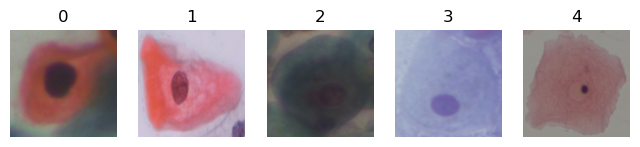

{0: 'im_Dyskeratotic', 1: 'im_Koilocytotic', 2: 'im_Metaplastic', 3: 'im_Parabasal', 4: 'im_Superficial-Intermediate'}


In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 5, figsize=(8,8))

for i in range(5):
    ax[i].imshow(sipakmed_data[i][0][0].permute(1,2,0))
    ax[i].axis('off')
    ax[i].set_title(i)
plt.show()
print(sipakmed_labels)

## 2.2) Train-Test split

In [13]:
'''
Classe im_Dyskeratotic: 813
Classe im_Koilocytotic: 825
Classe im_Metaplastic: 793
Classe im_Parabasal: 787
Classe im_Superficial-Intermediate: 831
'''
from torch.utils.data import random_split

def train_test_split():
    # 80% (treino) : 20% (teste + validação)
    # Proporções por classe (treino, teste+validação)
    sipakmed_prop = {0: (649,164), 1: (659,166), 2: (633,160), 3: (629,158), 4: (663,168)}
    
    sipakmed_training_data = []
    sipakmed_validation_data = []
    sipakmed_testing_data = []

    split_generator = torch.Generator().manual_seed(31)

    for i in range(5):
        train_size, test_val_size = sipakmed_prop[i]
        
        training_data, validation_data = random_split(
            sipakmed_data[i], [train_size, test_val_size], generator=split_generator
        )
        validation_data, testing_data = random_split(
            validation_data, [test_val_size//2, test_val_size//2], generator=split_generator
        )

        sipakmed_training_data.append(training_data)
        sipakmed_validation_data.append(validation_data)
        sipakmed_testing_data.append(testing_data)

    training_data = sipakmed_training_data[0] + sipakmed_training_data[1] + sipakmed_training_data[2] + sipakmed_training_data[3] + sipakmed_training_data[4]
    validation_data = sipakmed_validation_data[0] + sipakmed_validation_data[1] + sipakmed_validation_data[2] + sipakmed_validation_data[3] + sipakmed_validation_data[4]
    testing_data = sipakmed_testing_data[0] + sipakmed_testing_data[1] + sipakmed_testing_data[2] + sipakmed_testing_data[3] + sipakmed_testing_data[4]

    return training_data, validation_data, testing_data
    
training_data, validation_data, testing_data = train_test_split()

## 2.3) Dataloader

In [14]:
training_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
validation_dataloader = DataLoader(validation_data, batch_size=64, shuffle=True)
testing_dataloader = DataLoader(testing_data, batch_size=64)

In [18]:
for X,y in training_dataloader:
    print('X:', X.shape)
    print('y:', y)
    break

X: torch.Size([64, 3, 224, 224])
y: tensor([3, 1, 0, 4, 3, 4, 2, 2, 3, 4, 4, 3, 0, 4, 4, 4, 2, 3, 3, 0, 0, 4, 3, 1,
        3, 1, 1, 3, 3, 4, 3, 0, 0, 1, 1, 1, 1, 1, 3, 0, 2, 1, 0, 2, 3, 1, 2, 3,
        4, 3, 1, 3, 4, 1, 0, 3, 3, 0, 0, 0, 1, 2, 2, 1])


## 3.0) Using cuda device

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


## 3.1) Loading ResNet

In [19]:
model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)

Downloading: "https://github.com/pytorch/vision/zipball/v0.10.0" to C:\Users\Lucas/.cache\torch\hub\v0.10.0.zip
D:\miniconda3\envs\gpu\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\miniconda3\envs\gpu\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Lucas/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100.0%


In [24]:
# Estamos lidando com 5 classes
model.fc = nn.Linear(in_features=512, out_features=5, bias=True)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 3.2) Model setup

In [37]:
epochs = 50
best_loss = float('inf')
patience = 0
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
model = model.to(device)

## 3.3) Training loop

In [38]:
for i in range(epochs):
    print(f'Época {i+1}/{epochs}')
    model.train()
    batch = 0
    for X,y in training_dataloader:
        if batch % 10 == 0:
            print(f'  batch {batch+1}/{len(training_dataloader)}')
        batch += 1
        
        X = X.to(device)
        y = y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X,y in validation_dataloader:
            X = X.to(device)
            y = y.to(device)
    
            pred = model(X)
            loss = loss_fn(pred, y)
            total_loss += loss.item()
        
        total_loss = total_loss / len(validation_dataloader)
        if(total_loss < best_loss):
            best_loss = total_loss
            torch.save(model.state_dict(), root_dir / 'sipakmed.pth')
            patience = 0
        else:
            patience += 1
            if patience == 5:
                print('Early stopping...')
                break
    print(f'Fim da época {i+1}: val_loss = {total_loss}')

Época 1/50
  batch 1/51
  batch 11/51
  batch 21/51
  batch 31/51
  batch 41/51
  batch 51/51
Fim da época 1: val_loss = 1.1734774283000402
Época 2/50
  batch 1/51
  batch 11/51
  batch 21/51
  batch 31/51
  batch 41/51
  batch 51/51
Fim da época 2: val_loss = 0.9216245923723493
Época 3/50
  batch 1/51
  batch 11/51
  batch 21/51
  batch 31/51
  batch 41/51
  batch 51/51
Fim da época 3: val_loss = 0.6036087615149361
Época 4/50
  batch 1/51
  batch 11/51
  batch 21/51
  batch 31/51
  batch 41/51
  batch 51/51
Fim da época 4: val_loss = 0.5582067923886436
Época 5/50
  batch 1/51
  batch 11/51
  batch 21/51
  batch 31/51
  batch 41/51
  batch 51/51
Fim da época 5: val_loss = 0.4577020491872515
Época 6/50
  batch 1/51
  batch 11/51
  batch 21/51
  batch 31/51
  batch 41/51
  batch 51/51
Fim da época 6: val_loss = 0.47338236229760305
Época 7/50
  batch 1/51
  batch 11/51
  batch 21/51
  batch 31/51
  batch 41/51
  batch 51/51
Fim da época 7: val_loss = 0.3642927557229996
Época 8/50
  batch 

## 4.0) Loading best model

In [40]:
model.load_state_dict(torch.load(root_dir / 'sipakmed.pth', weights_only=True))
model.eval()
print()

## 4.1) Accuracy

In [52]:
with torch.no_grad():
    acc = 0
    for X,y in testing_dataloader:
        X = X.to(device)
        y = y.to(device)

        pred = model(X)
        acc += (pred.argmax(1) == y).sum().item()

    acc = acc / len(testing_data)

print(f'Acurácia: {(acc*100):.2f}%')

Acurácia: 95.10%


## 4.2) AUC

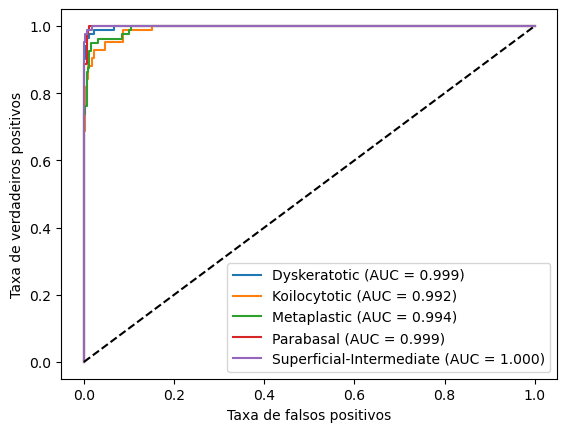

In [56]:
# Curva AUC
import numpy as np
from sklearn.metrics import roc_curve, auc

all_probs, all_labels = [], []

with torch.no_grad():
    for X, y in testing_dataloader:
        X = X.to(device)
        probs = torch.softmax(model(X), dim=1)
        all_probs.append(probs.cpu())
        all_labels.append(y)

probs = torch.cat(all_probs).numpy()      # (N, 5)
labels = torch.cat(all_labels).numpy()    # (N,)

classes = ['Dyskeratotic', 'Koilocytotic', 'Metaplastic', 'Parabasal', 'Superficial-Intermediate']

for i, nome in enumerate(classes):
    fpr, tpr, _ = roc_curve((labels == i).astype(int), probs[:, i])
    plt.plot(fpr, tpr, label=f'{nome} (AUC = {auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--')           # classificador aleatório
plt.xlabel('Taxa de falsos positivos')
plt.ylabel('Taxa de verdadeiros positivos')
plt.legend()
plt.show()